# 06 — DSTFS Trend Analysis

**Dave's Simple Trend Following System** — a composite trend indicator combining SMA(50) and HMA(15)
to produce a bias signal from -4 (max bearish) to +4 (max bullish).

The indicator uses 4 bias components:
- **Bias 1**: SMA direction (+1 rising, -1 falling)
- **Bias 2**: HMA direction (+1 rising, -1 falling)
- **Bias 3**: HMA > SMA → +1, else -1
- **Bias 4**: Close > HMA → +1, else -1

Chart layout: candlestick with color-segmented moving averages (top 70%), bias histogram (bottom 30%).

In [1]:
%load_ext autoreload
%autoreload 2

## 1. Connect and Fetch Candle Data

Load config, connect to TastyTrade, and fetch 1 year of daily SPX candles.

In [2]:
from options_analyzer.config import load_config
from options_analyzer.factory import create_providers

config = load_config()
providers = await create_providers(config)
market_data = providers.market_data
print(f"Connected to {providers.provider_name}.")

UNDERLYING = "SPX"
candles = await market_data.get_candles(UNDERLYING, interval="1d", days_back=180)
print(f"Fetched {len(candles)} daily candles for {UNDERLYING}")
print(f"Date range: {candles.timestamps[0]:%Y-%m-%d} to {candles.timestamps[-1]:%Y-%m-%d}")

Connected to TastyTrade (live).
Fetched 124 daily candles for SPX
Date range: 2025-09-17 to 2026-03-15


## 2. Compute DSTFS Indicator

Run the DSTFS computation on the close prices with default parameters (SMA=50, HMA=15).

In [3]:
from options_analyzer.engine.indicators import compute_dstfs

result = compute_dstfs(candles.closes)

# Current signal summary
import numpy as np

latest = len(result.close) - 1
print(f"DSTFS Signal Summary ({candles.timestamps[-1]:%Y-%m-%d})")
print(f"{'='*40}")
print(f"Close:       {result.close[latest]:>10.2f}")
print(f"SMA(50):     {result.sma[latest]:>10.2f}")
print(f"HMA(15):     {result.hma[latest]:>10.2f}")
print(f"{'─'*40}")
print(f"Bias 1 (SMA dir):    {result.bias1[latest]:>+4.0f}")
print(f"Bias 2 (HMA dir):    {result.bias2[latest]:>+4.0f}")
print(f"Bias 3 (HMA>SMA):    {result.bias3[latest]:>+4.0f}")
print(f"Bias 4 (Close>HMA):  {result.bias4[latest]:>+4.0f}")
print(f"{'─'*40}")
print(f"Total Bias:          {result.total_bias[latest]:>+4.0f}")

bias = result.total_bias[latest]
if bias >= 4:
    outlook = "STRONG BULLISH"
elif bias >= 2:
    outlook = "BULLISH"
elif bias == 0:
    outlook = "NEUTRAL"
elif bias >= -2:
    outlook = "BEARISH"
else:
    outlook = "STRONG BEARISH"
print(f"Outlook:             {outlook}")

DSTFS Signal Summary (2026-03-15)
Close:          6632.19
SMA(50):        6879.87
HMA(15):        6652.66
────────────────────────────────────────
Bias 1 (SMA dir):      -1
Bias 2 (HMA dir):      -1
Bias 3 (HMA>SMA):      -1
Bias 4 (Close>HMA):    -1
────────────────────────────────────────
Total Bias:            -4
Outlook:             STRONG BEARISH


## 3. DSTFS Candlestick Chart

Two-panel Bloomberg-themed chart:
- **Top**: Candlestick with color-segmented SMA (green/red) and HMA (teal/fuchsia)
- **Bottom**: Bias histogram colored by signal strength

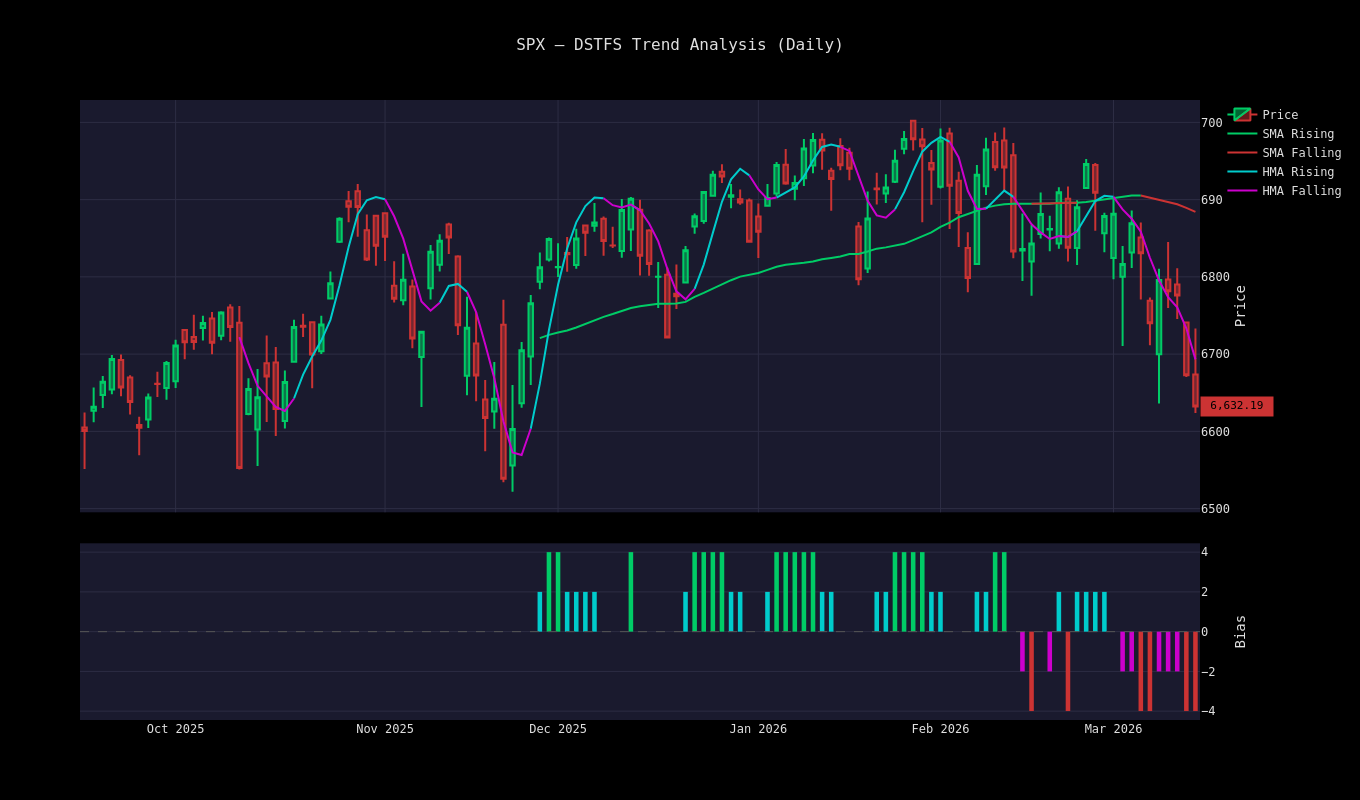

In [4]:
from options_analyzer.visualization.indicator_charts import plot_dstfs_candlestick

fig = plot_dstfs_candlestick(
    result,
    opens=candles.opens,
    highs=candles.highs,
    lows=candles.lows,
    timestamps=candles.timestamps,
    title=f"{UNDERLYING} — DSTFS Trend Analysis (Daily)",
)
fig.update_layout(height=800)
fig.show()

## 4. Market Conditions Full Dashboard

Fetch all required symbols and render the 6-panel composite chart:
**EMA Cloud** | **DSTFS Bias** | **MC Warning Squares** | **MC Warning Totals** | **IVTS** | **Borg Transwarp**

In [5]:
from options_analyzer.engine.borg_transwarp import BORG_TICKERS

# All symbols we need: 20 Borg tickers (includes SPY, QQQ) + VIX + VIX3M
extra_symbols = ["VIX", "VIX3M"]
all_symbols = list(dict.fromkeys(BORG_TICKERS + extra_symbols))  # deduplicated, order-preserving

print(f"Fetching {len(all_symbols)} symbols: {', '.join(all_symbols)}")

# Fetch all candle series concurrently with automatic timestamp alignment
candle_data = await market_data.get_candles_batch(all_symbols, interval="1d", days_back=1500)

Fetching 22 symbols: SPY, IOO, QQQ, VTV, XLF, XLP, TLT, SHV, AGG, IEF, PSQ, SH, BND, VWO, FDN, XLU, XLK, KMLM, SMH, HYD, VIX, VIX3M
  SPY: 1028 bars
  IOO: 1028 bars
  QQQ: 1028 bars
  VTV: 1028 bars
  XLF: 1028 bars
  XLP: 1028 bars
  TLT: 1028 bars
  SHV: 1028 bars
  AGG: 1028 bars
  IEF: 1028 bars
  PSQ: 1028 bars
  SH: 1028 bars
  BND: 1028 bars
  VWO: 1028 bars
  FDN: 1028 bars
  XLU: 1028 bars
  XLK: 1028 bars
  KMLM: 1028 bars
  SMH: 1028 bars
  HYD: 1028 bars
  VIX: 1029 bars
  VIX3M: 1028 bars

Fetched 22/22 symbols successfully (1029 bars, 2022-02-07 to 2026-03-15)


All indicators computed. SPY bars: 1029, Borg days: 1029


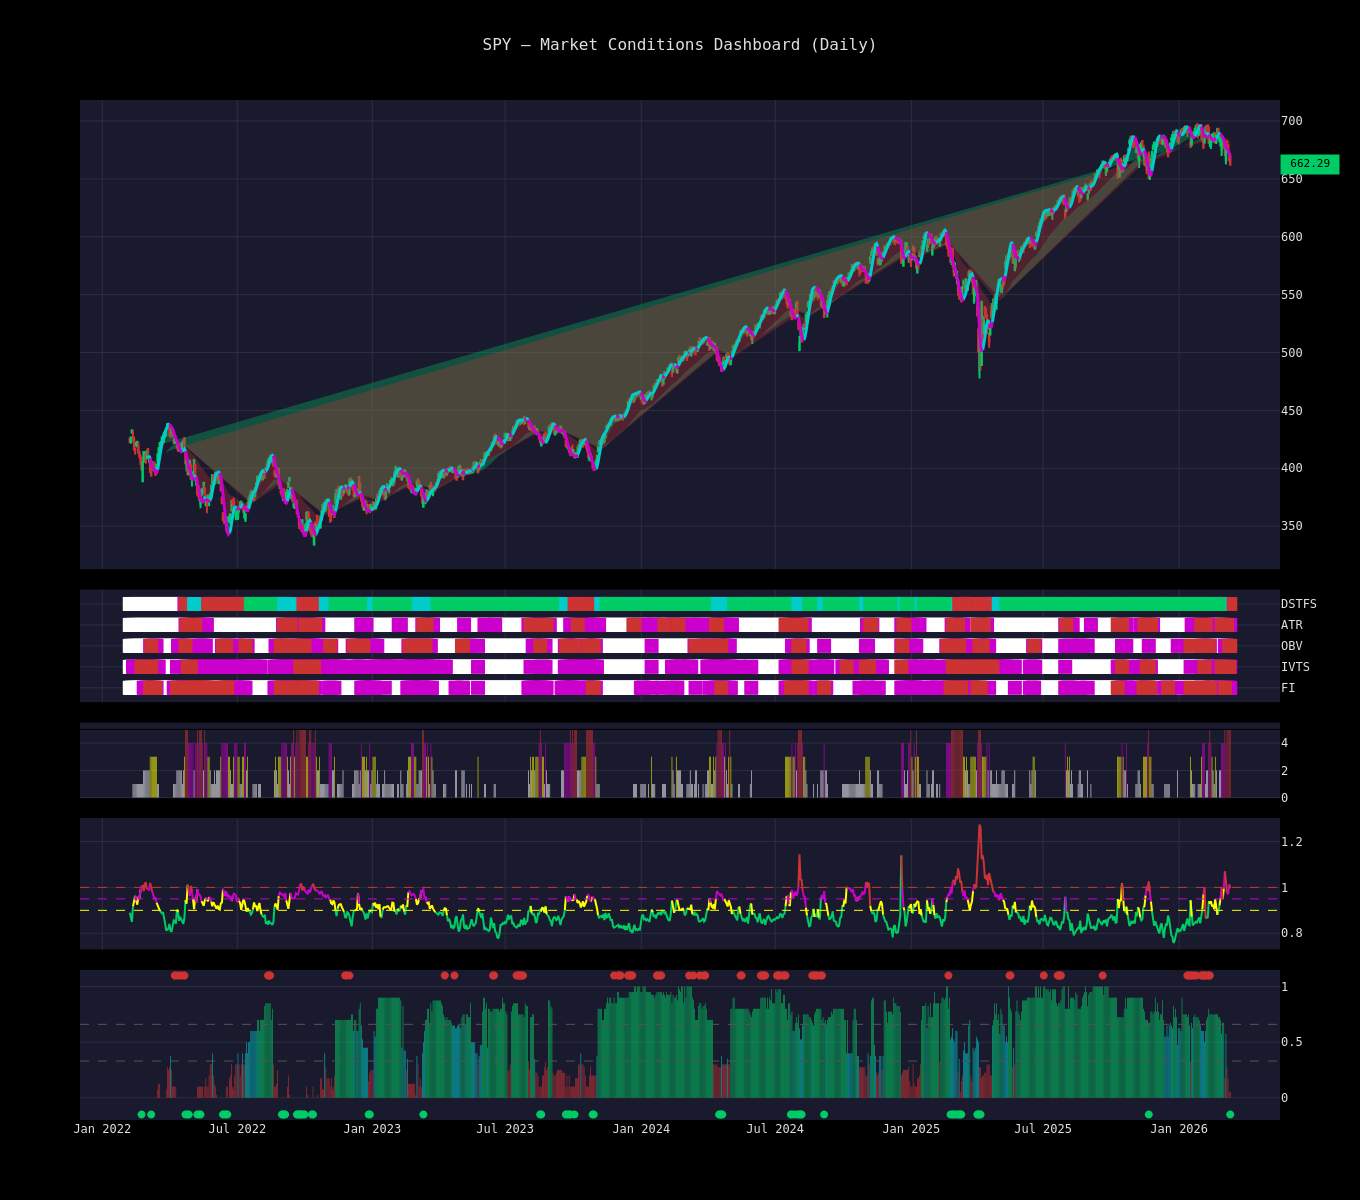

In [6]:
import numpy as np

from options_analyzer.engine.atr_bollinger import compute_atr_bollinger
from options_analyzer.engine.borg_transwarp import compute_borg_transwarp_series
from options_analyzer.engine.ema_cloud import compute_ema_cloud
from options_analyzer.engine.force_index import compute_force_index_dual
from options_analyzer.engine.ivts import compute_ivts
from options_analyzer.engine.mc_warnings import compute_mc_warnings
from options_analyzer.engine.obv_bollinger import compute_obv_bollinger
from options_analyzer.visualization.market_charts import plot_full_grid

spy = candle_data["SPY"]
qqq = candle_data["QQQ"]
vix = candle_data["VIX"]
vix3m = candle_data["VIX3M"]

# Compute all indicators
ema_result = compute_ema_cloud(spy.closes)
dstfs_spy = compute_dstfs(spy.closes)
atr_result = compute_atr_bollinger(spy.highs, spy.lows, spy.closes)
obv_result = compute_obv_bollinger(spy.closes, spy.volumes)
ivts_result = compute_ivts(vix.closes, vix3m.closes)
fi_result = compute_force_index_dual(spy.closes, spy.volumes, qqq.closes, qqq.volumes)
mc_result = compute_mc_warnings(atr_result, obv_result, ivts_result, fi_result, dstfs_spy)

# Borg Transwarp needs all 20 ticker closes
borg_closes = {sym: candle_data[sym].closes for sym in BORG_TICKERS if sym in candle_data}
borg_results = compute_borg_transwarp_series(borg_closes)

print(f"All indicators computed. SPY bars: {len(spy)}, Borg days: {len(borg_results)}")

# Render full dashboard
fig = plot_full_grid(
    ema_cloud_result=ema_result,
    dstfs_result=dstfs_spy,
    mc_result=mc_result,
    ivts_result=ivts_result,
    borg_results=borg_results,
    opens=spy.opens,
    highs=spy.highs,
    lows=spy.lows,
    closes=spy.closes,
    timestamps=spy.timestamps,
    title="SPY — Market Conditions Dashboard (Daily)",
)
fig.show()

In [7]:
# Current MC Warnings status
latest = len(mc_result.total) - 1
date_str = spy.timestamps[-1].strftime("%Y-%m-%d")

print(f"MC Warnings Summary ({date_str})")
print(f"{'='*45}")

labels = ["ATR Bollinger", "OBV Bollinger", "IVTS", "Force Index", "DSTFS"]
severities = [
    mc_result.atr_severity[latest],
    mc_result.obv_severity[latest],
    mc_result.ivts_severity[latest],
    mc_result.fi_severity[latest],
    mc_result.dstfs_warning[latest],
]
severity_map = {0: "OK", 1: "WARNING", 2: "DANGER"}

for label, sev in zip(labels, severities):
    sev_int = int(sev) if not np.isnan(sev) else 0
    status = severity_map.get(sev_int, f"?({sev_int})")
    marker = {0: " ", 1: "!", 2: "X"}.get(sev_int, "?")
    print(f"  [{marker}] {label:<16s} {status}")

total = int(mc_result.total[latest]) if not np.isnan(mc_result.total[latest]) else 0
print(f"{'─'*45}")
print(f"  Total warnings: {total}/5")

# Borg Transwarp latest
if borg_results:
    borg_latest = borg_results[-1]
    print(f"\nBorg Transwarp ({date_str})")
    print(f"{'='*45}")
    print(f"  QQQ allocation:  {borg_latest.qqq:.1%}")
    print(f"  Overbought:      {'YES' if borg_latest.overbought else 'no'}")
    print(f"  Oversold:        {'YES' if borg_latest.oversold else 'no'}")

MC Warnings Summary (2026-03-14)
  [ ] ATR Bollinger    OK
  [X] OBV Bollinger    DANGER
  [!] IVTS             WARNING
  [!] Force Index      WARNING
  [!] DSTFS            WARNING
─────────────────────────────────────────────
  Total warnings: 4/5

Borg Transwarp (2026-03-14)
  QQQ allocation:  5.0%
  Overbought:      no
  Oversold:        YES


## 5. Standalone Demo (No Provider Needed)

Demonstrate DSTFS with synthetic data — useful for testing without TastyTrade credentials.

In [ ]:
import numpy as np

from options_analyzer.engine.indicators import compute_dstfs
from options_analyzer.visualization.indicator_charts import plot_dstfs

# Generate synthetic price data: uptrend → sideways → downtrend
rng = np.random.default_rng(42)
n = 300
trend = np.concatenate([
    np.linspace(5000, 5500, 100),       # uptrend
    np.full(100, 5500) + rng.normal(0, 20, 100),  # sideways
    np.linspace(5500, 5000, 100),       # downtrend
])
noise = rng.normal(0, 10, n)
synthetic_close = trend + noise

result_synth = compute_dstfs(synthetic_close)
fig = plot_dstfs(result_synth, title="DSTFS — Synthetic Data (Up → Sideways → Down)")
fig.update_layout(height=600)
fig.show()

print(f"Final bias: {result_synth.total_bias[-1]:+.0f}")

## 6. Cleanup

In [ ]:
await providers.disconnect()
print("Session disconnected.")